# Parameter-first T1–T2 DETR retraining

**Prepared 2026-07-24 — new data, new config, new result name**

This notebook is the hand-off for the next full training run. It answers four questions:

1. What changed from the finalized baseline?
2. How is T1/T2 loss weighted by compartment signal fraction?
3. Why are T1, T2, and weight recovery now the primary accuracy criteria?
4. Which commands produce the full, thesis-ready result without overwriting the baseline?

The included two-epoch result is only a **pipeline smoke test** on 192 voxels. It proves
that the new loss, checkpoint choice, threshold calibration, metrics, and figures execute
end to end. It is not a scientific performance result.

In [1]:
from pathlib import Path
import json

import pandas as pd
import yaml
from IPython.display import HTML, Image, Markdown, display

pd.set_option("display.max_colwidth", 100)
pd.set_option("display.width", 160)

candidates = [Path.cwd(), Path.cwd().parent]
PROJECT_ROOT = next(
    (p.resolve() for p in candidates
     if (p / "configs" / "t1_3500_t2_500_weighted_long.yaml").exists()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Run from t1t2_component_detection/ or its notebooks/ directory."
    )

CONFIG_PATH = PROJECT_ROOT / "configs" / "t1_3500_t2_500_weighted_long.yaml"
AUDIT_DIR = PROJECT_ROOT / "results" / "data_audit" / "t1_3500_t2_500_100k"
SMOKE_DIR = (
    PROJECT_ROOT / "results" /
    "smoke_t1_3500_t2_500_weighted_long_20260724_v2"
)
FULL_DIR = PROJECT_ROOT / "results" / "t1_3500_t2_500_weighted_long"
OLD_BASELINE = PROJECT_ROOT / "results" / "baseline_final_100k"

config = yaml.safe_load(CONFIG_PATH.read_text())
audit = json.loads((AUDIT_DIR / "audit_summary.json").read_text())
smoke = json.loads((SMOKE_DIR / "summary.json").read_text())

def show_image(path, width=1200):
    if not path.exists():
        raise FileNotFoundError(path)
    display(Image(filename=str(path), width=width))

display(HTML('''
<style>
  .decision {border-left:5px solid #0969da;background:#f6f8fa;padding:10px 14px;
             margin:12px 0}
  .warning {border-left:5px solid #d29922;background:#fff8c5;padding:10px 14px;
            margin:12px 0}
  .ready {border-left:5px solid #1a7f37;background:#dafbe1;padding:10px 14px;
          margin:12px 0}
</style>
'''))

print(f"Project root: {PROJECT_ROOT}")
print(f"New full result directory: {FULL_DIR}")

Project root: /Users/fatihozkan/Desktop/Thesis/t1t2_component_detection
New full result directory: /Users/fatihozkan/Desktop/Thesis/t1t2_component_detection/results/t1_3500_t2_500_weighted_long


## 1. Preservation boundary

The completed baseline remains the thesis reference. No old configuration, checkpoint,
result JSON, figure, or notebook is used as the output target of this experiment.

| Artifact | Historical baseline | Parameter-first retraining |
|---|---|---|
| Config | `configs/baseline_final_100k.yaml` | `configs/t1_3500_t2_500_weighted_long.yaml` |
| Data | existing baseline family | `data/t1_3500_t2_500_100k/` |
| Results | `results/baseline_final_100k/` | `results/t1_3500_t2_500_weighted_long/` |
| Notebook | `finalized_baseline_walkthrough_2026_07_24.ipynb` | this dated notebook |

<div class="decision"><b>Compatibility decision:</b> the old loss reduction, fixed
threshold, total-loss checkpoint selection, constant learning rate, and no clipping
remain the code defaults. The new behavior is activated only by fields in the new YAML.
Old configs therefore retain their old semantics.</div>

In [2]:
preservation = pd.DataFrame([
    {
        "artifact": "finalized baseline",
        "path": str(OLD_BASELINE.relative_to(PROJECT_ROOT)),
        "exists": OLD_BASELINE.exists(),
        "role": "frozen thesis reference",
    },
    {
        "artifact": "new dataset",
        "path": "data/t1_3500_t2_500_100k",
        "exists": (PROJECT_ROOT / "data/t1_3500_t2_500_100k").exists(),
        "role": "new experiment only",
    },
    {
        "artifact": "new full result",
        "path": str(FULL_DIR.relative_to(PROJECT_ROOT)),
        "exists": FULL_DIR.exists(),
        "role": "created when full training starts",
    },
])
display(preservation)

,artifact,path,exists,role
0,finalized baseline,results/baseline_final_100k,True,frozen thesis reference
1,new dataset,data/t1_3500_t2_500_100k,True,new experiment only
2,new full result,results/t1_3500_t2_500_weighted_long,False,created when full training starts


## 2. New synthetic family

Requested constraints:

\[
50 \le T_1 \le 3500\text{ ms},\qquad
5 \le T_2 \le 500\text{ ms},\qquad
T_1 > T_2.
\]

The generator remains deliberately simple: log-uniform random compartments, symmetric
Dirichlet signal fractions with a 5% minimum, signed IR-MSE signals, and real additive
Gaussian noise. No tissue prototypes or magnitude/Rician noise were introduced.

The family contains 33,333 training voxels for each of `n=1,2,3`, for **99,999 training
voxels total**. Validation, test, and fixed-SNR ladder sets are generated separately.

In [3]:
rows = audit["rows"]
row_table = pd.DataFrame(rows).T
row_table.loc["TOTAL"] = row_table.sum(axis=0)
display(row_table.astype(int))

audit_table = pd.DataFrame([
    ("Audit passed", audit["passed"]),
    ("Checks", audit["checks_total"]),
    ("Failures", audit["checks_failed"]),
    ("T1 bounds", audit["requested_bounds"]["t1"]),
    ("T2 bounds", audit["requested_bounds"]["t2"]),
    ("Physical constraint", audit["requested_bounds"]["constraint"]),
], columns=["Item", "Recorded value"])
display(audit_table)

if not audit["passed"]:
    raise RuntimeError("The new data audit failed; do not train.")

,train,val,test,test_snr20,test_snr40,test_snr60,test_snr100,test_snr150
n1,33333,3333,3333,1667,1667,1667,1667,1667
n2,33333,3333,3333,1667,1667,1667,1667,1667
n3,33333,3333,3333,1667,1667,1667,1667,1667
TOTAL,99999,9999,9999,5001,5001,5001,5001,5001


,Item,Recorded value
0,Audit passed,True
1,Checks,426
2,Failures,0
3,T1 bounds,"[50.0, 3500.0]"
4,T2 bounds,"[5.0, 500.0]"
5,Physical constraint,T1>T2


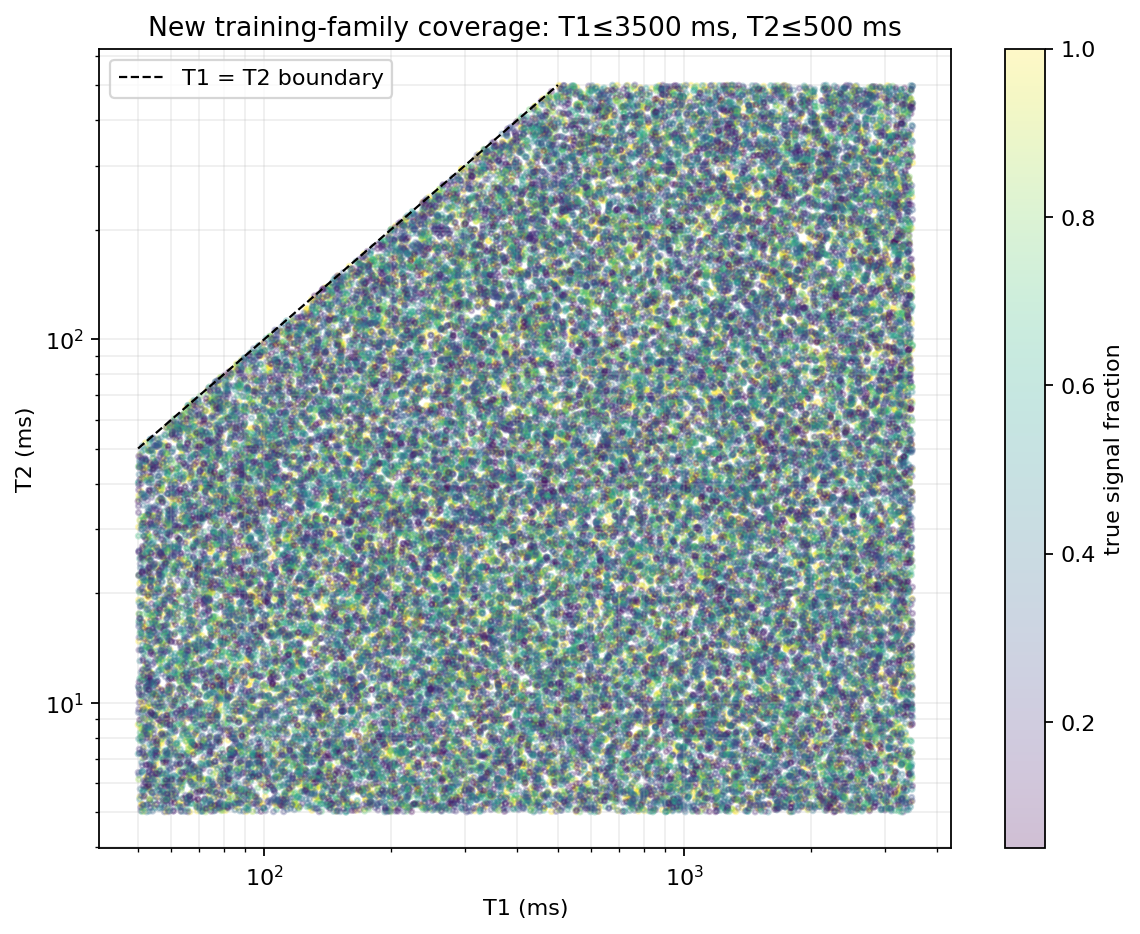

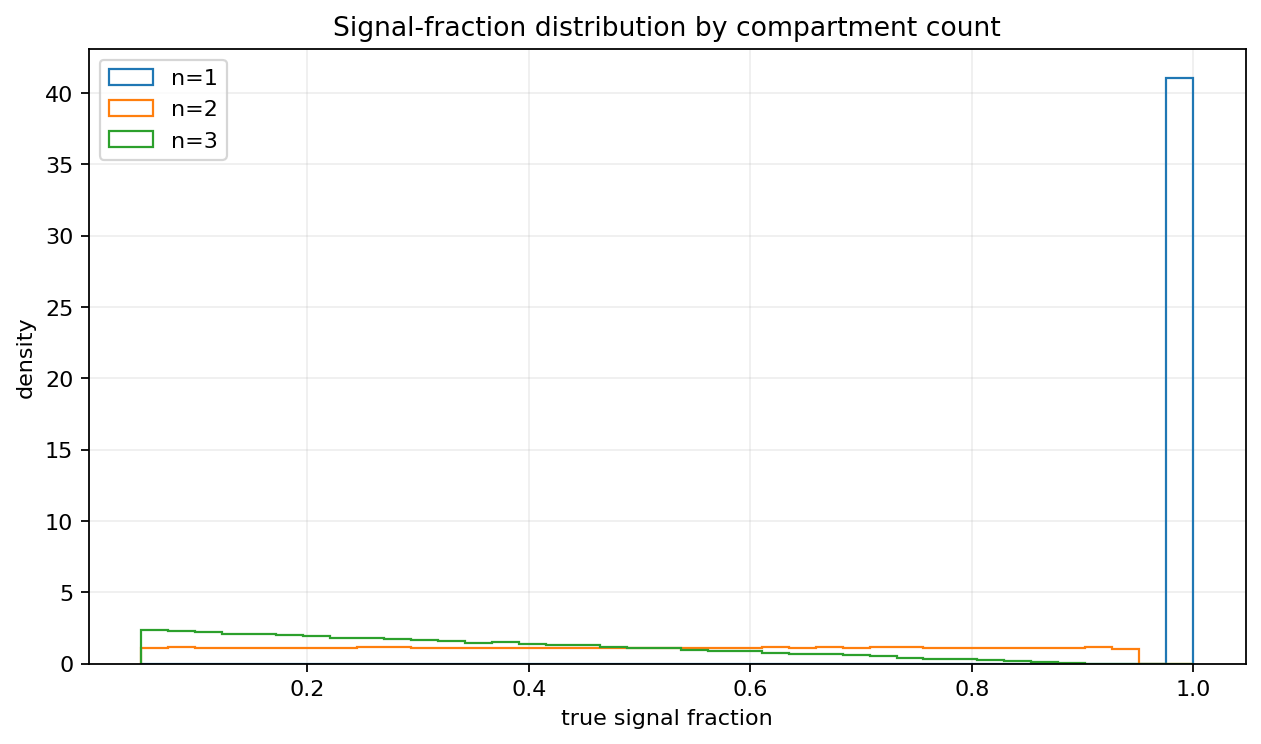

In [4]:
show_image(AUDIT_DIR / "coverage.png", width=850)
show_image(AUDIT_DIR / "signal_fraction_distribution.png", width=850)

## 3. Signal-fraction-weighted T1/T2 loss

Let \(w_c\) be the true signal fraction of compartment \(c\). T1 and T2 are first mapped
to log-minmax coordinates \(z\in[0,1]\). After Hungarian matching, the new per-voxel
losses are

\[
L_{T1} =
\frac{\sum_c w_c(\hat z_{T1,c}-z_{T1,c})^2}{\sum_c w_c},
\qquad
L_{T2} =
\frac{\sum_c w_c(\hat z_{T2,c}-z_{T2,c})^2}{\sum_c w_c}.
\]

Since the target fractions sum to one, this is the signal-fraction-weighted expectation
of the squared error. A 60% compartment therefore contributes six times as much T1/T2
supervision as a 10% compartment.

The historical implementation already multiplied T1/T2 error by \(w_c\), but then
divided by the number of compartments. That made the entire T1/T2 term two times smaller
for `n=2` and three times smaller for `n=3`. The new `signal_fraction` mode divides by
\(\sum w_c\), which removes that unintended count-dependent down-scaling.

Weight error stays a separate, uniformly averaged matched-compartment term:
\[
L_w = \operatorname{mean}_c(\hat w_c-w_c)^2.
\]
This keeps weak-compartment fractions visible instead of weighting the weight error by
the same fraction it is trying to estimate.

In [5]:
toy = pd.DataFrame({
    "compartment": ["dominant", "weak"],
    "signal fraction": [0.90, 0.10],
    "normalized squared T1 error": [0.01, 0.25],
})
toy["weighted contribution"] = (
    toy["signal fraction"] * toy["normalized squared T1 error"]
)
legacy = toy["weighted contribution"].sum() / len(toy)
intended = toy["weighted contribution"].sum() / toy["signal fraction"].sum()
uniform = toy["normalized squared T1 error"].mean()
display(toy)
display(pd.DataFrame([
    ("historical reduction", legacy, "preserved for old configs"),
    ("new signal-fraction reduction", intended, "used by this run"),
    ("uniform ablation", uniform, "available, not selected"),
], columns=["Reduction", "Toy loss", "Role"]))

,compartment,signal fraction,normalized squared T1 error,weighted contribution
0,dominant,0.9,0.01,0.009
1,weak,0.1,0.25,0.025


,Reduction,Toy loss,Role
0,historical reduction,0.017,preserved for old configs
1,new signal-fraction reduction,0.034,used by this run
2,uniform ablation,0.130,"available, not selected"


## 4. What “accuracy” means in this run

Exact compartment-count accuracy is useful, but it cannot be the main scientific
outcome. A model can predict the correct count with physically wrong T1/T2/weights, or
miss a very weak pool while accurately recovering nearly all signal mass.

The primary report is now the recovered parameter set:

- signal-fraction-weighted relative T1 error;
- signal-fraction-weighted relative T2 error;
- weight set L1 error, including missed and extra compartments;
- recovered true signal fraction;
- T1/T2 error and recovery rate as a function of true signal fraction.

Matching for this analysis uses all three primary outputs: log-T1, log-T2, and weight.
Exact count accuracy, count MAE, precision, recall, and F1 remain secondary diagnostics.

<div class="decision"><b>Checkpoint rule:</b> choose the best epoch on validation
\(L_{T1}+L_{T2}+L_w\). Existence loss still trains the existence head but cannot decide
which checkpoint is “best.”</div>

<div class="decision"><b>Threshold rule:</b> sweep existence threshold on validation and
minimize a bounded parameter-set error that includes T1, T2, missed signal mass, weight
error, and extra predicted weight. Freeze that threshold before test evaluation. The
bounded composite is only a selection rule; the unbounded physical errors remain the
thesis quantities to interpret.</div>

In [6]:
loss_cfg = config["loss"]
train_cfg = config["train"]
eval_cfg = config["evaluation"]
decisions = pd.DataFrame([
    ("T1/T2 reduction", loss_cfg["t1_t2_weighting"],
     "dominant signal fractions receive proportionally more supervision"),
    ("T1:T2:weight coefficients",
     f"{loss_cfg['t1_weight']}:{loss_cfg['t2_weight']}:{loss_cfg['w_weight']}",
     "equal normalized-coordinate importance"),
    ("Existence coefficient", loss_cfg["exist_weight"],
     "trained, but secondary to parameter recovery"),
    ("Checkpoint selection", train_cfg["selection_metric"],
     "validation T1 + T2 + weight"),
    ("Threshold objective", eval_cfg["threshold_objective"],
     "validation-only parameter set recovery"),
], columns=["Decision", "Value", "Reason"])
display(decisions)

,Decision,Value,Reason
0,T1/T2 reduction,signal_fraction,dominant signal fractions receive proportionally more supervision
1,T1:T2:weight coefficients,1.0:1.0:1.0,equal normalized-coordinate importance
2,Existence coefficient,0.1,"trained, but secondary to parameter recovery"
3,Checkpoint selection,parameter_loss,validation T1 + T2 + weight
4,Threshold objective,parameter_set_error,validation-only parameter set recovery


## 5. Longer, safer optimization configuration

The 500 epochs are an upper bound, not a promise to run all 500. Training stops after 35
validation epochs without meaningful parameter-loss improvement. A plateau scheduler
reduces the learning rate before early stopping, and gradient clipping protects against
unusually large updates. The best checkpoint is saved independently from the last
resumable checkpoint.

In [7]:
training_table = pd.DataFrame([
    ("Epoch ceiling", train_cfg["epochs"]),
    ("Batch size", train_cfg["batch_size"]),
    ("Initial learning rate", train_cfg["lr"]),
    ("Weight decay", train_cfg["weight_decay"]),
    ("Early-stop patience", train_cfg["early_stopping_patience"]),
    ("Minimum validation improvement", train_cfg["early_stopping_min_delta"]),
    ("LR schedule", train_cfg["lr_scheduler"]),
    ("LR reduction factor", train_cfg["scheduler_factor"]),
    ("Scheduler patience", train_cfg["scheduler_patience"]),
    ("Minimum learning rate", train_cfg["scheduler_min_lr"]),
    ("Gradient clip norm", train_cfg["gradient_clip_norm"]),
    ("Random seed", train_cfg["seed"]),
], columns=["Setting", "Value"])
display(training_table)

,Setting,Value
0,Epoch ceiling,500
1,Batch size,512
2,Initial learning rate,0.0001
3,Weight decay,0.0001
4,Early-stop patience,35
5,Minimum validation improvement,0.00001
6,LR schedule,reduce_on_plateau
7,LR reduction factor,0.5
8,Scheduler patience,7
9,Minimum learning rate,0.000001


## 6. End-to-end smoke test

<div class="warning"><b>Not a thesis result:</b> the following model saw only 192 training
voxels for two epochs. Its errors measure undertraining, not the method. The purpose is
to verify the new pipeline and artifact contract before a long cluster job.</div>

In [8]:
recovery = smoke["detr"]["parameter_recovery"]["summary"]
smoke_checks = pd.DataFrame([
    ("Epochs completed", smoke["epochs_run"]),
    ("Best epoch", smoke["best_epoch"]),
    ("Checkpoint selection field", smoke["selection_metric"]),
    ("Best validation parameter loss", smoke["best_parameter_val_loss"]),
    ("Validation-selected threshold",
     smoke["threshold_calibration"]["selected_threshold"]),
    ("Recovered signal fraction (smoke only)",
     recovery["recovered_signal_fraction"]),
    ("Parameter-set accuracy (smoke only)",
     recovery["parameter_set_accuracy"]),
], columns=["Pipeline check", "Observed value"])
display(smoke_checks)

required = [
    "parameter_scatter_detr.png",
    "error_vs_signal_fraction_detr.png",
    "recovery_vs_signal_fraction_detr.png",
    "threshold_calibration.png",
]
figure_check = pd.DataFrame([
    (name, (SMOKE_DIR / "figures" / name).exists()) for name in required
], columns=["Required new figure", "Created"])
display(figure_check)

,Pipeline check,Observed value
0,Epochs completed,2
1,Best epoch,2
2,Checkpoint selection field,parameter_loss
3,Best validation parameter loss,0.138384
4,Validation-selected threshold,0.58
5,Recovered signal fraction (smoke only),0.931835
6,Parameter-set accuracy (smoke only),0.347872


,Required new figure,Created
0,parameter_scatter_detr.png,True
1,error_vs_signal_fraction_detr.png,True
2,recovery_vs_signal_fraction_detr.png,True
3,threshold_calibration.png,True


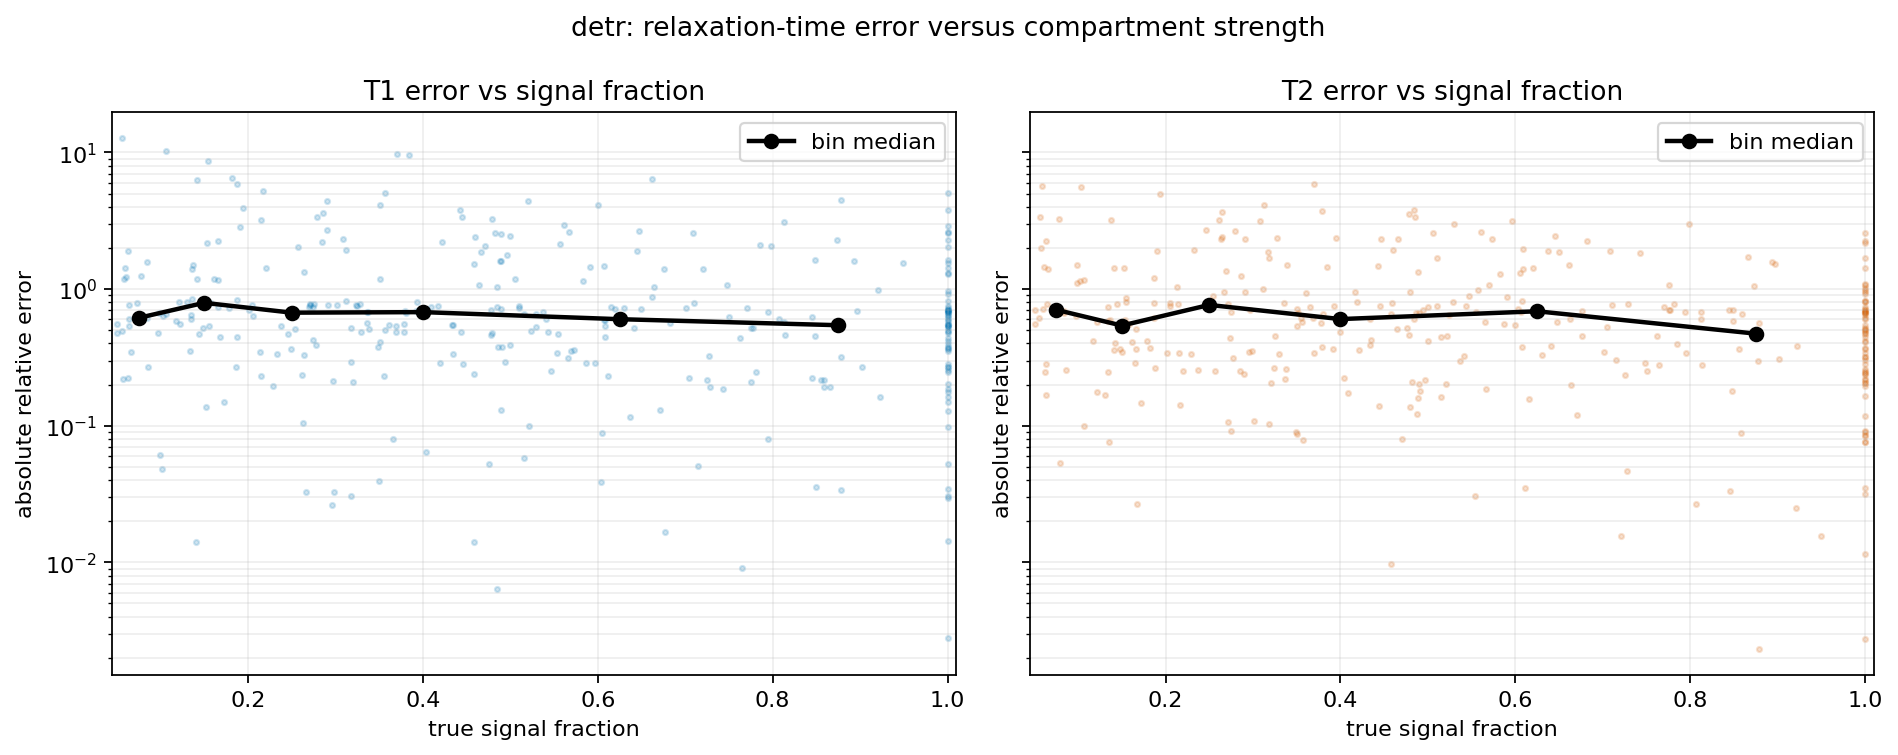

In [9]:
show_image(SMOKE_DIR / "figures" / "error_vs_signal_fraction_detr.png")

The dots are individual matched compartments; the black line is the median inside each
signal-fraction bin. A log y-axis keeps both small and very large relative errors visible.
In the full result, this is the direct test of the hypothesis behind the new loss:
parameter error should generally improve as the compartment contributes more signal.

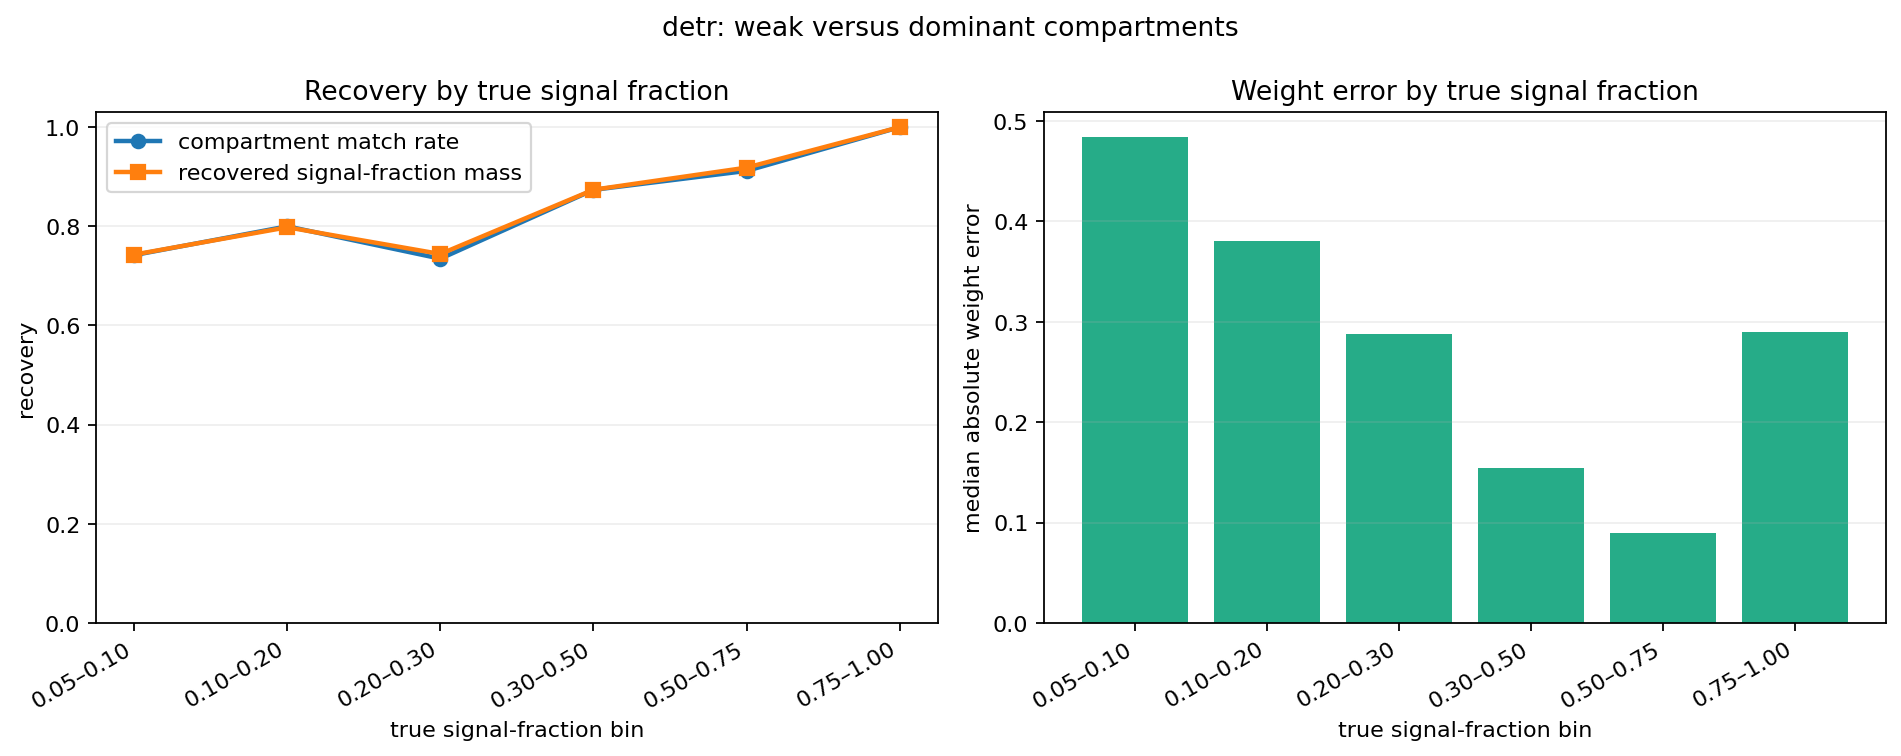

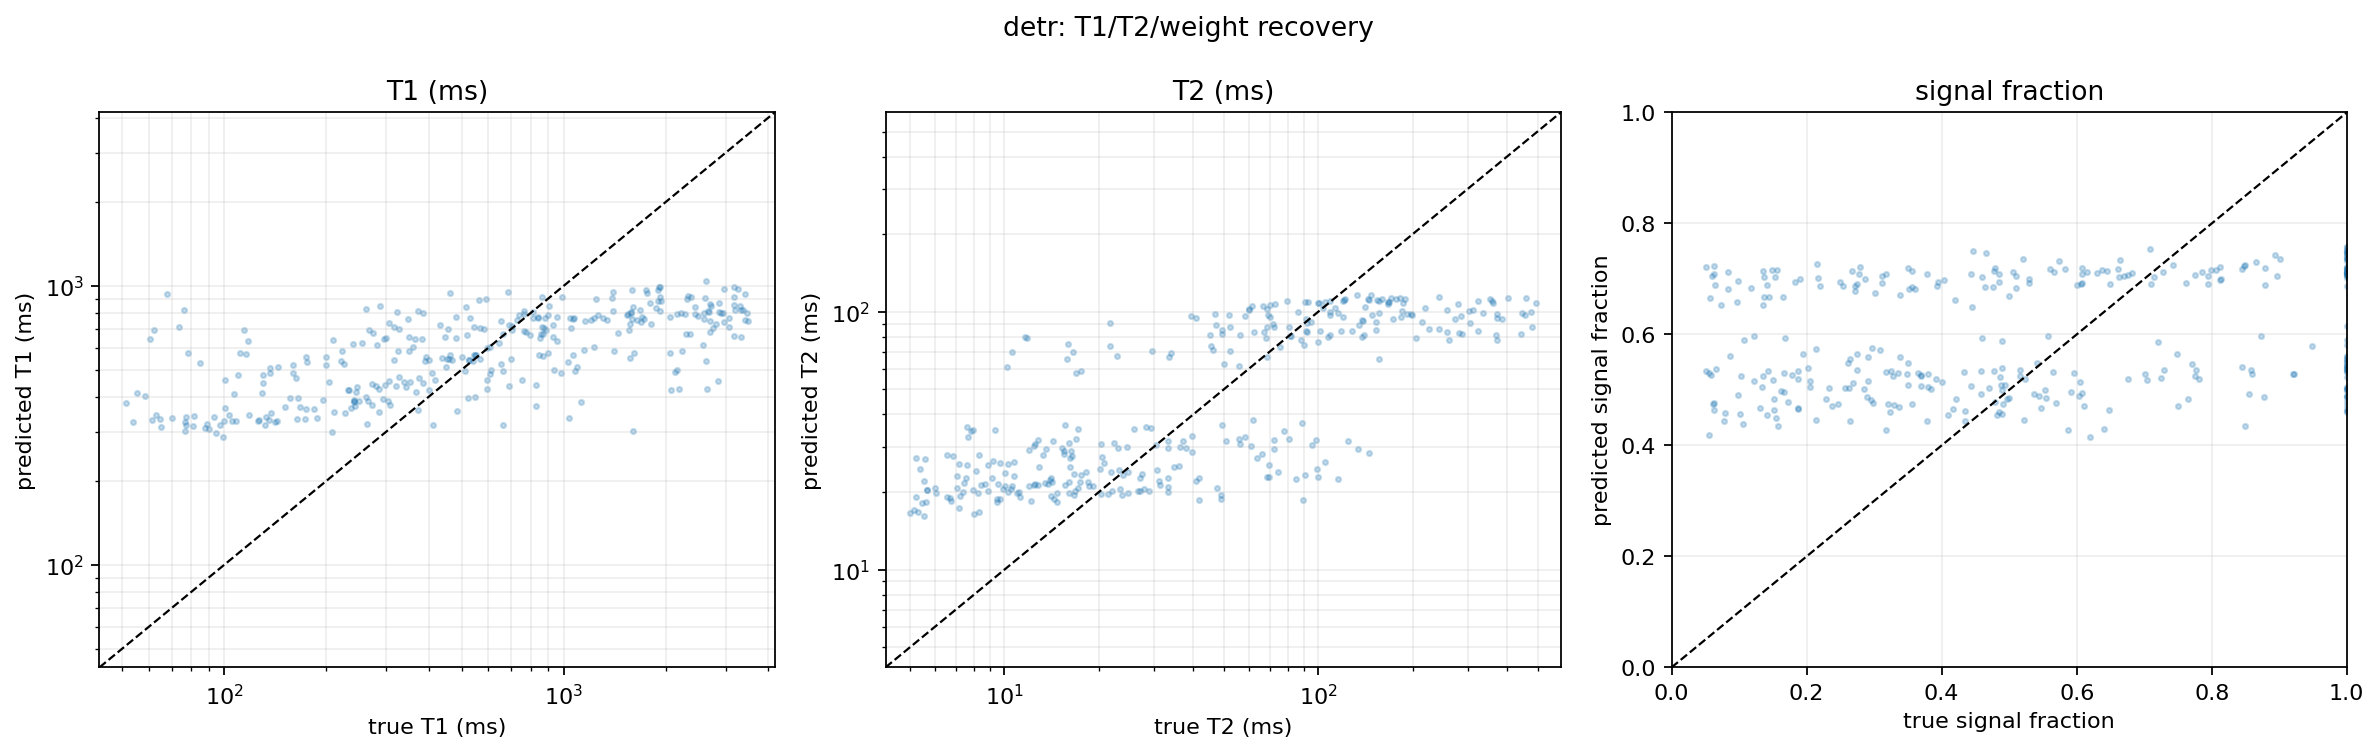

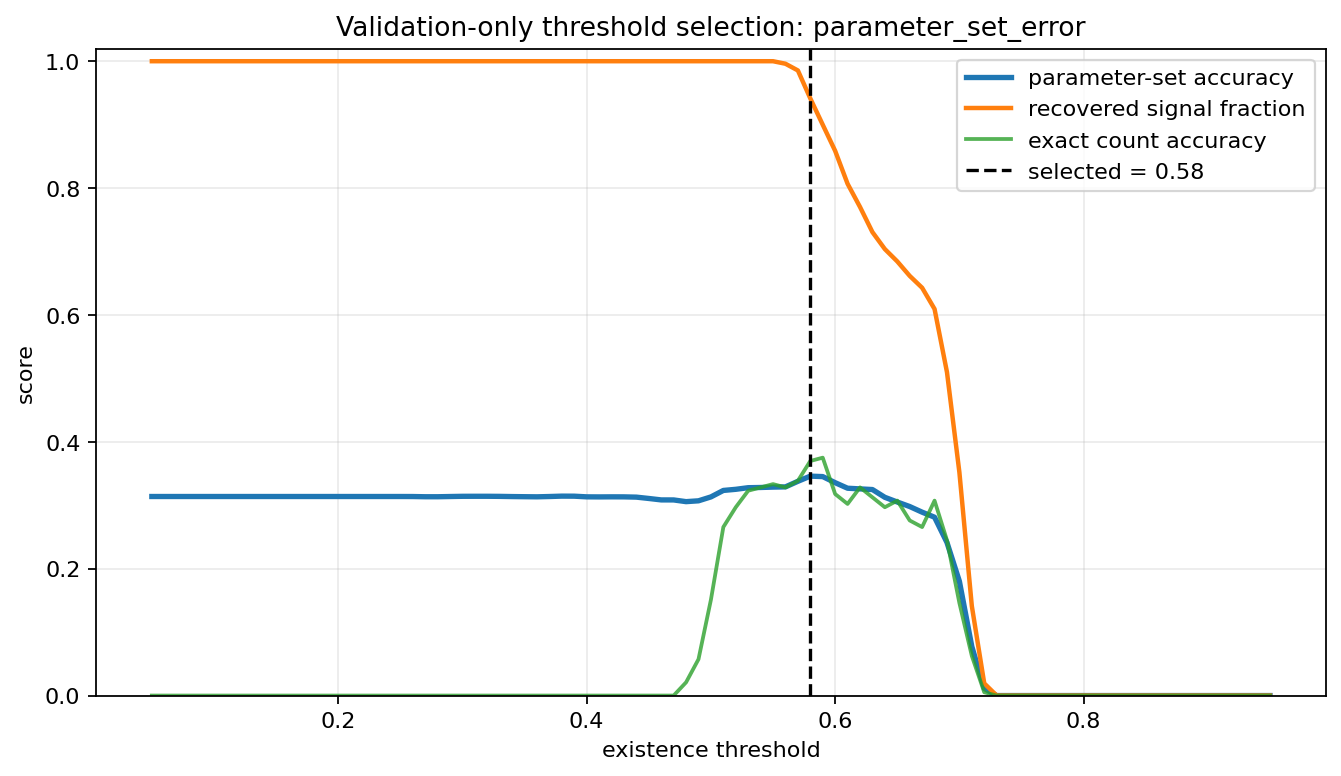

In [10]:
show_image(SMOKE_DIR / "figures" / "recovery_vs_signal_fraction_detr.png")
show_image(SMOKE_DIR / "figures" / "parameter_scatter_detr.png")
show_image(SMOKE_DIR / "figures" / "threshold_calibration.png")

## 7. Full training commands

The dataset is already generated and audited locally. On the cluster, generate and audit
the same isolated family first:

```bash
sbatch slurm/gen_data_t1_3500_t2_500_100k.slurm
sbatch slurm/audit_t1_3500_t2_500_100k.slurm
```

After the audit job reports `passed: true`, start the long run:

```bash
sbatch slurm/train_t1_3500_t2_500_weighted_long.slurm
```

Or run directly from the project root:

```bash
PYTHONPATH=src python3 -m t1t2.experiment \
  --config configs/t1_3500_t2_500_weighted_long.yaml
```

The full job writes only to `results/t1_3500_t2_500_weighted_long/`. If interrupted, the
same command resumes from `checkpoints/last.pt`; the final evaluation reloads
`checkpoints/best.pt`.

## 8. Thesis reporting order after the full run

1. State the held-out test set and the validation-only selection rules.
2. Report recovered signal fraction.
3. Report signal-fraction-weighted T1 and T2 relative errors.
4. Report weight set L1 error and matched-compartment weight error.
5. Show T1/T2 error versus signal fraction and recovery versus signal fraction.
6. Show predicted-versus-true T1, T2, and weight.
7. Report count accuracy/MAE and existence precision/recall as secondary diagnostics.
8. Report the paired SNR ladder to show noise sensitivity.

<div class="ready"><b>Ready state:</b> the new data passed its hard audit; the new loss,
parameter-first model selection, validation-only thresholding, and plots passed both the
automated test suite and an isolated end-to-end training smoke test. The remaining
expensive step is the full cluster training run.</div>